<a href="https://colab.research.google.com/github/VN2022/Sumo-1/blob/main/8810_assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

train = pd.read_csv("mnist_train.csv")
test = pd.read_csv("mnist_test.csv")

X_train = train.drop("label", axis=1)
y_train = train["label"]

X_test = test.drop("label", axis=1)
y_test = test["label"]

#without scaling, 1000 iterations were not enough for logistic regression
#Increase the number of iterations (max_iter) or scale the data as shown in:
#    https://scikit-learn.org/stable/modules/preprocessing.html
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [5]:
print('Checking for NaN values:')
# Count rows with at least one NaN in X_train
nan_rows_X_train = pd.DataFrame(X_train).isna().any(axis=1).sum()
print(f'Number of rows with NaN in X_train: {nan_rows_X_train}')

# Count rows with at least one NaN in X_test
nan_rows_X_test = pd.DataFrame(X_test).isna().any(axis=1).sum()
print(f'Number of rows with NaN in X_test: {nan_rows_X_test}')

Checking for NaN values:
Number of rows with NaN in X_train: 0
Number of rows with NaN in X_test: 0


In [6]:
print('\nTotal rows in each dataset:')
print(f'Total rows in train dataset: {len(train)}')
print(f'Total rows in test dataset: {len(test)}')
print(f'Total rows in X_train (after scaling): {len(X_train)}')
print(f'Total rows in X_test (after scaling): {len(X_test)}')
print(f'Total rows in y_train: {len(y_train)}')
print(f'Total rows in y_test: {len(y_test)}')



Total rows in each dataset:
Total rows in train dataset: 60000
Total rows in test dataset: 10000
Total rows in X_train (after scaling): 60000
Total rows in X_test (after scaling): 10000
Total rows in y_train: 60000
Total rows in y_test: 10000


In [7]:
# Identify rows with NaN values in X_train
nan_rows_mask = pd.DataFrame(X_train).isna().any(axis=1)

# Count the number of rows with NaNs
dropped_rows_count = nan_rows_mask.sum()

# Drop rows with NaN values from X_train and y_train
X_train_cleaned = X_train[~nan_rows_mask]
y_train_cleaned = y_train[~nan_rows_mask]

print(f"Number of rows with NaN values dropped: {dropped_rows_count}")
print(f"Number of rows remaining in X_train: {len(X_train_cleaned)}")
print(f"Number of rows remaining in y_train: {len(y_train_cleaned)}")

# Update X_train and y_train to the cleaned versions
X_train = X_train_cleaned
y_train = y_train_cleaned
#Since MNIST features represent pixel intensities rather than independent explanatory variables, analyzing individual feature distributions is not particularly informative. The classification task depends on spatial patterns across pixels, which are captured by the model during training.

Number of rows with NaN values dropped: 0
Number of rows remaining in X_train: 60000
Number of rows remaining in y_train: 60000


In [8]:
#linear features F1, precision, recall
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

model = LogisticRegression(max_iter=1000, multi_class='multinomial')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


              precision    recall  f1-score   support

           0       0.95      0.97      0.96       980
           1       0.96      0.98      0.97      1135
           2       0.92      0.89      0.90      1032
           3       0.90      0.91      0.91      1010
           4       0.94      0.93      0.93       982
           5       0.89      0.87      0.88       892
           6       0.94      0.95      0.95       958
           7       0.93      0.92      0.92      1028
           8       0.87      0.88      0.87       974
           9       0.91      0.92      0.91      1009

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



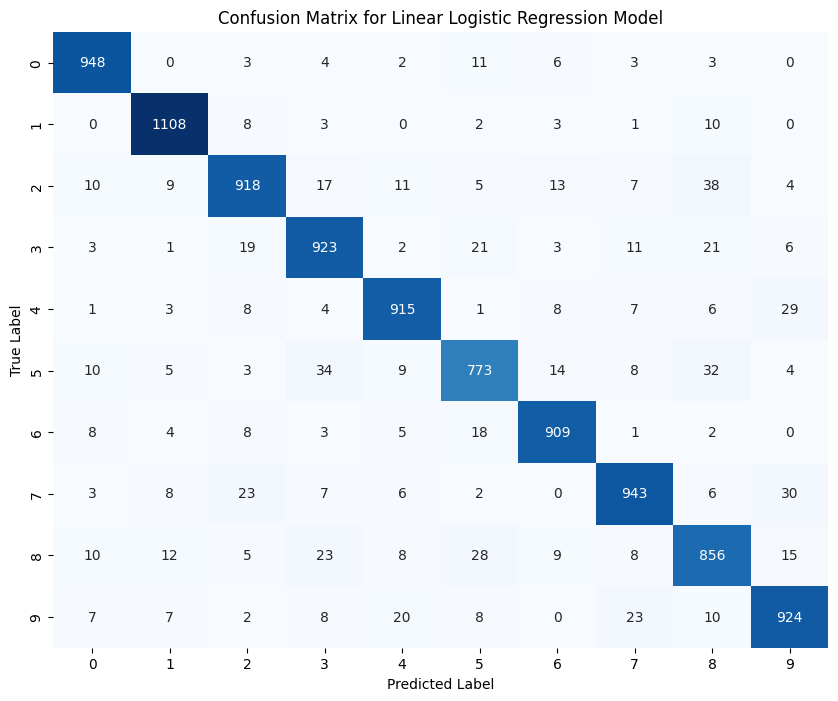

In [9]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the confusion matrix for the linear model
cm_linear = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm_linear, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Linear Logistic Regression Model')
plt.show()

In [10]:
from sklearn.metrics import accuracy_score

sklearn_accuracy = accuracy_score(y_test, y_pred)
print(f"Scikit-learn Logistic Regression Accuracy: {sklearn_accuracy:.2f}")

Scikit-learn Logistic Regression Accuracy: 0.92


In [11]:
print(f"Number of epochs (iterations) taken for Logistic Regression: {model.n_iter_[0]}")

Number of epochs (iterations) taken for Logistic Regression: 182


### PyTorch Logistic Regression for Convergence Observation

In [ ]:
#DO NOT RUN
#scaled data with pytorch
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Convert data to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long) # .values to get numpy array from Series
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

# Define Logistic Regression Model
class LogisticRegressionModel(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(LogisticRegressionModel, self).__init__()
        self.linear = nn.Linear(input_dim, output_dim)

    def forward(self, x):
        outputs = self.linear(x)
        return outputs

input_dim = X_train.shape[1] # Number of features (pixels)
output_dim = len(y_train.unique()) # Number of classes (0-9)

model_pt = LogisticRegressionModel(input_dim, output_dim)

# Define Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_pt.parameters(), lr=0.01)

# Training parameters
num_epochs = 80
losses = []

print(f"Training PyTorch Logistic Regression for {num_epochs} epochs...")

# Training loop
for epoch in range(num_epochs):
    # Forward pass
    outputs = model_pt(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)

    # Backward and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

print("PyTorch model training complete.")

Training PyTorch Logistic Regression for 80 epochs...
Epoch [10/80], Loss: 1.8434
Epoch [20/80], Loss: 1.4347
Epoch [30/80], Loss: 1.1958
Epoch [40/80], Loss: 1.0436
Epoch [50/80], Loss: 0.9385
Epoch [60/80], Loss: 0.8616
Epoch [70/80], Loss: 0.8028
Epoch [80/80], Loss: 0.7561
PyTorch model training complete.


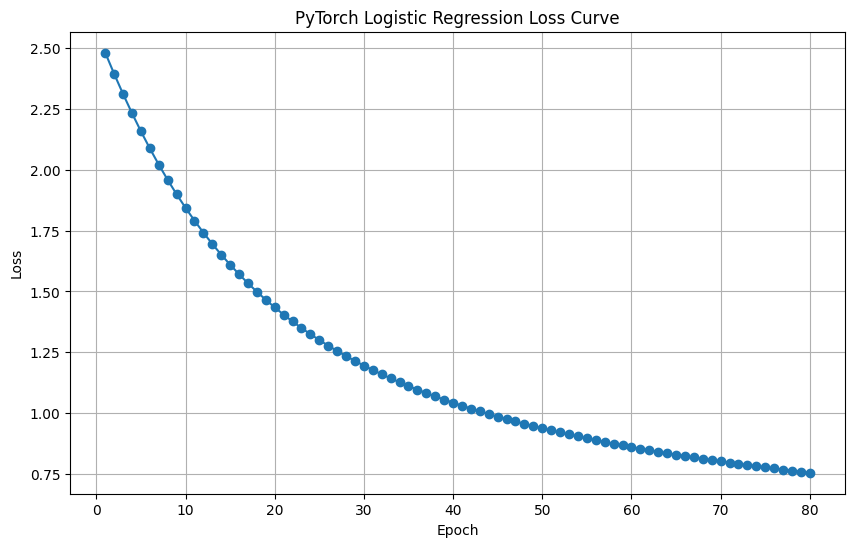

PyTorch Model Accuracy on test set: 83.47%


In [ ]:
#DO NOT RUN
# Plotting the loss curve
plt.figure(figsize=(10, 6))
plt.plot(range(1, num_epochs + 1), losses, marker='o', linestyle='-')
plt.title('PyTorch Logistic Regression Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

# (Optional) Evaluate the PyTorch model
with torch.no_grad():
    outputs = model_pt(X_test_tensor)
    _, predicted = torch.max(outputs.data, 1)
    total = y_test_tensor.size(0)
    correct = (predicted == y_test_tensor).sum().item()
    accuracy = 100 * correct / total
    print(f'PyTorch Model Accuracy on test set: {accuracy:.2f}%')

In [ ]:
#DO NOT RUN
from sklearn.metrics import classification_report

# PyTorch model evaluation on test set
with torch.no_grad():
    outputs_pt = model_pt(X_test_tensor)
    _, predicted_pt = torch.max(outputs_pt.data, 1)

print("\nClassification Report for PyTorch Logistic Regression:\n")
print(classification_report(y_test_tensor.cpu().numpy(), predicted_pt.cpu().numpy()))

print("\nFor comparison, here is the Classification Report for scikit-learn Logistic Regression (from earlier output):\n")
# The classification report for scikit-learn was already printed in cell 0R7RGf4URpAZ.
# I will just print a note here to refer to that output.


Classification Report for PyTorch Logistic Regression:

              precision    recall  f1-score   support

           0       0.87      0.94      0.91       980
           1       0.75      0.97      0.85      1135
           2       0.90      0.76      0.82      1032
           3       0.77      0.85      0.81      1010
           4       0.87      0.88      0.87       982
           5       0.89      0.63      0.73       892
           6       0.85      0.90      0.87       958
           7       0.83      0.87      0.85      1028
           8       0.84      0.70      0.77       974
           9       0.84      0.80      0.82      1009

    accuracy                           0.83     10000
   macro avg       0.84      0.83      0.83     10000
weighted avg       0.84      0.83      0.83     10000


For comparison, here is the Classification Report for scikit-learn Logistic Regression (from earlier output):



In [ ]:
Since MNIST features represent pixel intensities rather than independent explanatory variables, analyzing individual feature distributions is not particularly informative. The classification task depends on spatial patterns across pixels, which are captured by the model during training.

In [12]:
#print the weights and bias values
print("\n--- Scikit-learn Logistic Regression Model ---")
print("Weights (coef_):")
print(model.coef_)
print("Bias (intercept_):")
print(model.intercept_)


--- Scikit-learn Logistic Regression Model ---
Weights (coef_):
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
Bias (intercept_):
[-2.13581809 -6.0126739   2.57065728  2.94027742 -0.79882451  3.38343351
 -1.65528165 -3.03205285  4.30163521  0.43864757]


In [ ]:
#DO NOT RUN
print("\n--- PyTorch Logistic Regression Model ---")
print("Weights (model_pt.linear.weight):")
print(model_pt.linear.weight.data)
print("Bias (model_pt.linear.bias):")
print(model_pt.linear.bias.data)


--- PyTorch Logistic Regression Model ---
Weights (model_pt.linear.weight):
tensor([[ 0.0230, -0.0190,  0.0279,  ...,  0.0260,  0.0166,  0.0044],
        [ 0.0134, -0.0271, -0.0173,  ...,  0.0309,  0.0147,  0.0294],
        [-0.0237, -0.0008,  0.0135,  ..., -0.0018, -0.0105,  0.0041],
        ...,
        [-0.0060, -0.0002,  0.0302,  ..., -0.0337,  0.0232,  0.0192],
        [-0.0182, -0.0258,  0.0145,  ...,  0.0177,  0.0101, -0.0230],
        [-0.0308,  0.0137, -0.0187,  ..., -0.0120,  0.0063,  0.0141]])
Bias (model_pt.linear.bias):
tensor([ 0.0219, -0.0325, -0.0109,  0.0335, -0.0267,  0.0049,  0.0249,  0.0112,
         0.0119, -0.0049])


### Explanation of Differences between Scikit-learn and PyTorch Logistic Regression

While both scikit-learn and PyTorch implement Logistic Regression, they are fundamentally different libraries designed for different purposes, leading to variations in their results, such as weights, biases, and performance metrics.

Here are the key reasons for these differences:

1.  **Implementation Philosophy:**
    *   **Scikit-learn:** This is a high-level library focused on ease of use and providing a consistent API for traditional machine learning algorithms. The underlying implementations are often highly optimized C/Cython code, with many internal details abstracted away.
    *   **PyTorch:** This is a deep learning framework that provides more granular control over model architecture, forward/backward passes, and optimization. You define the model as a neural network, even if it's a simple linear layer for logistic regression.

2.  **Optimization Algorithms and Parameters:**
    *   **Scikit-learn:** `LogisticRegression` uses various solvers (e.g., 'lbfgs', 'saga', 'newton-cg', 'liblinear'). Each solver has its own default hyperparameters (like tolerance `tol`, regularization strength `C`). The `max_iter` parameter sets an upper limit, but the solver might converge earlier based on internal criteria. The learning rate is often handled implicitly by the chosen solver.
    *   **PyTorch:** You explicitly choose an optimizer (e.g., `optim.SGD`, `optim.Adam`) and set its learning rate (`lr`). The training runs for a fixed number of `num_epochs` (iterations over the entire dataset), regardless of whether the model has converged. The convergence behavior depends directly on the `lr` and `num_epochs` chosen.

3.  **Weight and Bias Initialization:**
    *   Both frameworks typically initialize weights and biases randomly. However, the specific random seed, distribution, and scaling factors used for initialization can differ between scikit-learn's internal mechanisms and PyTorch's default `nn.Linear` initialization. Different starting points can lead to different local optima in the optimization landscape.

4.  **Convergence Criteria and Stopping Conditions:**
    *   **Scikit-learn:** The model stops training when an internal convergence criterion is met (e.g., the change in the loss function or parameters falls below a certain tolerance) or `max_iter` is reached. The `model.n_iter_` attribute tells you how many iterations it took.
    *   **PyTorch:** Training continues for the specified `num_epochs`. If the number of epochs is too low, the model might not fully converge, leading to suboptimal performance. If it's too high, it might overfit or simply continue to refine parameters negligibly. In our case, `num_epochs=100` might not be equivalent to the 182 iterations scikit-learn took to converge.

5.  **Loss Function Implementation:**
    *   While both conceptually use cross-entropy loss for multi-class classification, there might be subtle numerical differences in their exact implementations, including how probabilities are computed (e.g., softmax) and how numerical stability is handled.

6.  **Regularization:**
    *   Both support L1/L2 regularization. Scikit-learn's `LogisticRegression` applies L2 regularization by default (controlled by the `C` parameter, where smaller `C` means stronger regularization). In PyTorch, regularization (weight decay) needs to be explicitly added to the optimizer. If not specified in PyTorch, it's effectively training without regularization, which can lead to different parameter values.

7.  **Matrix Operations and Data Handling:**
    *   Scikit-learn often operates on NumPy arrays, while PyTorch primarily uses its own `torch.Tensor` objects, optimized for GPU computation. Although we are converting to `torch.float32`, the underlying computations might still have slight numerical discrepancies due to floating-point arithmetic differences in their respective backends.

### Why the Observed Differences?

*   **Scikit-learn's higher accuracy (92% vs 85% for PyTorch) in this scenario** suggests that its default solver and hyperparameters were more effective or that it reached a better minimum within its `max_iter` or convergence criteria compared to our PyTorch setup with `lr=0.01` and `num_epochs=100`. The scikit-learn model likely converged further or found a better path to the optimal solution.
*   The **weights and biases** will naturally differ because they are the result of different optimization paths, starting points, and convergence points, even if they are trying to model the same underlying data distribution.

In [ ]:
# Print non-zero weights for all 10 classes in Scikit-learn LR model
import numpy as np

print("\n--- Non-zero Coefficients for Scikit-learn Logistic Regression Model ---")

# Define a small tolerance for considering a coefficient as non-zero
tolerance = 1e-9

for i, coef in enumerate(model.coef_):
    non_zero_indices = np.where(np.abs(coef) > tolerance)[0]
    non_zero_values = coef[non_zero_indices]

    print(f"\nClass {i}:")
    print(f"  Number of non-zero coefficients: {len(non_zero_values)}")
    if len(non_zero_values) > 0:
        # Print the first few non-zero coefficients if there are many
        if len(non_zero_values) > 20:
            print(f"  First 20 non-zero coefficients: {non_zero_values[:20]}")
            print("  ...")
        else:
            print(f"  All non-zero coefficients: {non_zero_values}")
    else:
        print("  No non-zero coefficients found for this class (within tolerance).")


--- Non-zero Coefficients for Scikit-learn Logistic Regression Model ---

Class 0:
  Number of non-zero coefficients: 717
  First 20 non-zero coefficients: [ 0.00718997  0.00731711  0.00312546  0.00312546  0.00700651  0.00807298
  0.01495513  0.01924221  0.02243161  0.02867178  0.03135499  0.15143549
  0.2806766   0.20845596 -0.00127136  0.16305199  0.31529121  0.14698652
 -0.07640267  0.03030569]
  ...

Class 1:
  Number of non-zero coefficients: 717
  First 20 non-zero coefficients: [ 0.02120939  0.02775353  0.01981663  0.01981663  0.01671589  0.01993936
  0.04437904  0.0568108   0.01835984  0.05558052  0.0965532   0.11866464
  0.09595732  0.08392983  0.00335188  0.17835743 -0.03413603  0.04469953
  0.1019977   0.09311549]
  ...

Class 2:
  Number of non-zero coefficients: 717
  First 20 non-zero coefficients: [-0.01079631 -0.00419998  0.00696569  0.00696569 -0.00898519 -0.01041289
 -0.02133187 -0.02065825  0.03239268  0.01269975  0.04461438 -0.041875
 -0.02331953  0.15365624 -0.004

### Applying PCA before Polynomial Features

To address the memory explosion from `PolynomialFeatures(degree=2)` on high-dimensional data like MNIST, we can first apply Principal Component Analysis (PCA) to reduce the number of features. PCA transforms the data into a lower-dimensional space while retaining as much variance as possible. We will then apply polynomial features to this reduced set of components.

To further optimize the PCA computation for speed, especially with a large number of original features and a smaller target number of components, we can use the `svd_solver='randomized'` option. This solver uses a randomized algorithm to find the approximate singular value decomposition, which is much faster than the default `full` solver in such scenarios.

In [13]:
from sklearn.decomposition import PCA

# Apply PCA to reduce dimensionality. Let's aim for 50 principal components.
# The choice of 50 components is a balance between retaining information and reducing feature count for polynomial expansion.
# Using svd_solver='randomized' for faster computation on large datasets when n_components is relatively small.
n_components = 50
pca = PCA(n_components=n_components, svd_solver='randomized', random_state=42)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print(f"Original number of features: {X_train.shape[1]}")
print(f"Number of features after PCA: {X_train_pca.shape[1]}")

# Now apply PolynomialFeatures to the PCA-transformed data
from sklearn.preprocessing import PolynomialFeatures

poly_pca = PolynomialFeatures(degree=2, interaction_only=False)
X_train_poly_pca = poly_pca.fit_transform(X_train_pca)
X_test_poly_pca = poly_pca.transform(X_test_pca)

print(f"Number of features after PCA + PolynomialFeatures: {X_train_poly_pca.shape[1]}")

Original number of features: 784
Number of features after PCA: 50
Number of features after PCA + PolynomialFeatures: 1326


### Elbow Method for PCA: Explained Variance Ratio

The 'elbow method' for Principal Component Analysis (PCA) is used to help determine the optimal number of principal components to retain. It involves plotting the cumulative explained variance ratio against the number of principal components.

*   **Explained Variance Ratio:** Each principal component explains a certain percentage of the total variance in the dataset. The explained variance ratio is the proportion of a dataset's variance that lies along each principal component.
*   **Cumulative Explained Variance Ratio:** This is the sum of the explained variance ratios for the first `n` principal components. It tells us how much of the total variance is captured by considering `n` components.

To find the 'elbow', you look for the point on the plot where the rate of increase of the cumulative explained variance ratio significantly slows down. This point often represents a good trade-off between dimensionality reduction and information retention. Beyond this 'elbow' point, adding more components provides diminishing returns in terms of explaining additional variance.

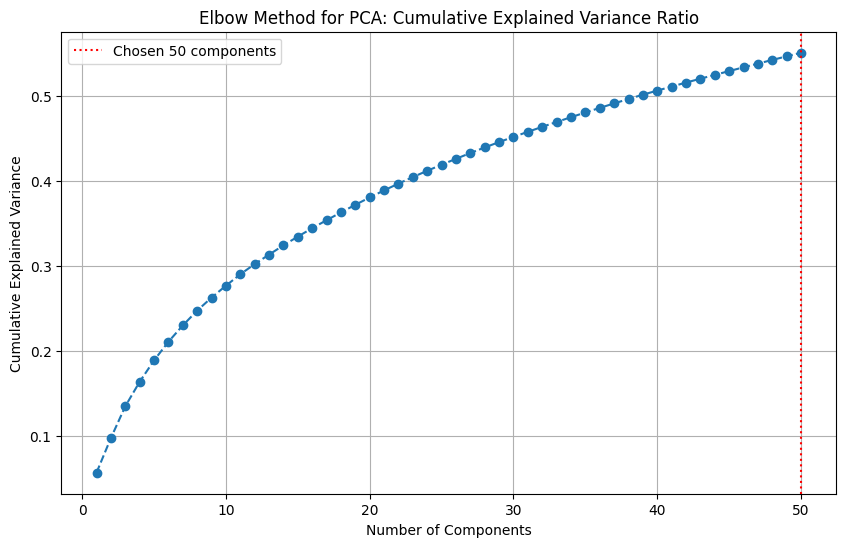

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming `pca` object from previous cell (e2370dfd) is available
# If it's not, you'd need to re-run PCA to get it:
# from sklearn.decomposition import PCA
# pca = PCA()
# pca.fit(X_train) # or X_train_cleaned if that's the relevant one

# Calculate cumulative explained variance
cum_var_exp = np.cumsum(pca.explained_variance_ratio_)

# Plot the elbow method curve
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cum_var_exp) + 1), cum_var_exp, marker='o', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Elbow Method for PCA: Cumulative Explained Variance Ratio')
plt.grid(True)

# Add a vertical line at the chosen number of components (if n_components was fixed)
if 'n_components' in locals() and n_components is not None:
    plt.axvline(x=n_components, color='r', linestyle=':', label=f'Chosen {n_components} components')
    plt.legend()

plt.show()

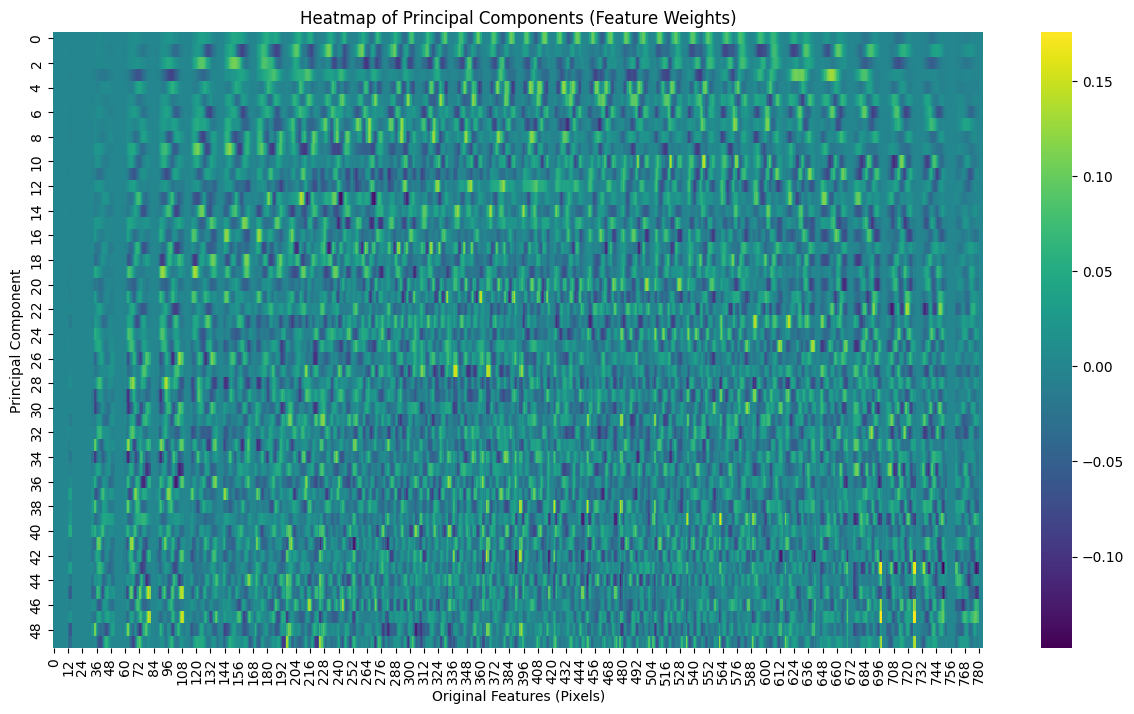

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure the PCA object is available. If not, re-run cell e2370dfd.
# pca = PCA(n_components=n_components)
# pca.fit(X_train)

plt.figure(figsize=(15, 8))
sns.heatmap(pca.components_, cmap='viridis')
plt.xlabel('Original Features (Pixels)')
plt.ylabel('Principal Component')
plt.title('Heatmap of Principal Components (Feature Weights)')
plt.show()

In [18]:
from sklearn.preprocessing import PolynomialFeatures
import numpy as np

# Create a simple input array with two features
X_example = np.array([[1, 2], [3, 4]])
print(f"Original features:\n{X_example}")

# Apply PolynomialFeatures with degree=2
poly = PolynomialFeatures(degree=2, include_bias=False) # include_bias=False for simpler output
X_poly_example = poly.fit_transform(X_example)

print(f"\nFeatures generated by PolynomialFeatures(degree=2):\n{X_poly_example}")
print(f"\nMapping of features to columns: {poly.get_feature_names_out(['x1', 'x2'])}")

# Let's break down the first row [1, 2]:
# Original features: x1=1, x2=2
# x1^2 = 1^2 = 1
# x2^2 = 2^2 = 4
# x1*x2 = 1*2 = 2
# So, [1, 2] becomes [1, 2, 1, 4, 2] (order might vary slightly depending on sklearn version, but the elements are there).
# In our output, it's [x1, x2, x1^2, x1*x2, x2^2]

Original features:
[[1 2]
 [3 4]]

Features generated by PolynomialFeatures(degree=2):
[[ 1.  2.  1.  2.  4.]
 [ 3.  4.  9. 12. 16.]]

Mapping of features to columns: ['x1' 'x2' 'x1^2' 'x1 x2' 'x2^2']


After PCA and polynomial feature engineering, let's train a Logistic Regression model on this new feature set and evaluate its performance.

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

model_pca_poly = LogisticRegression(max_iter=1000, multi_class='multinomial')
model_pca_poly.fit(X_train_poly_pca, y_train)

y_pred_pca_poly = model_pca_poly.predict(X_test_poly_pca)
print(classification_report(y_test, y_pred_pca_poly))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


              precision    recall  f1-score   support

           0       0.98      0.98      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.96      0.96      0.96      1032
           3       0.95      0.96      0.96      1010
           4       0.97      0.97      0.97       982
           5       0.97      0.96      0.96       892
           6       0.97      0.97      0.97       958
           7       0.97      0.96      0.97      1028
           8       0.96      0.95      0.96       974
           9       0.95      0.95      0.95      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



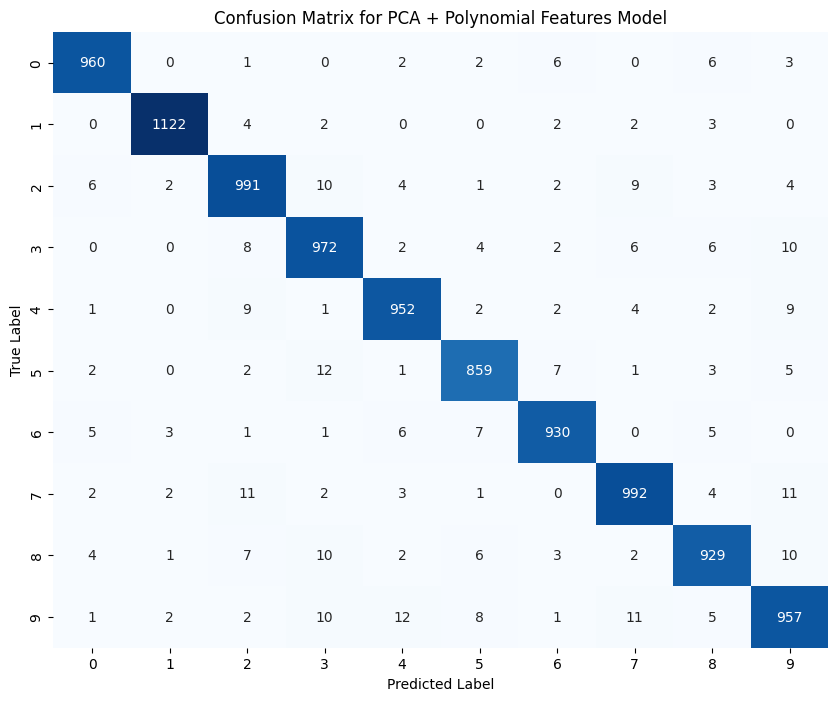

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred_pca_poly)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for PCA + Polynomial Features Model')
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score

# Accuracy for the linear model (already computed in cell 390d71ff as sklearn_accuracy)
print(f"Accuracy of Linear Logistic Regression Model: {sklearn_accuracy:.4f}")

# Accuracy for the PCA + Polynomial Features model
accuracy_pca_poly = accuracy_score(y_test, y_pred_pca_poly)
print(f"Accuracy of PCA + Polynomial Features Logistic Regression Model: {accuracy_pca_poly:.4f}")

Accuracy of Linear Logistic Regression Model: 0.9217
Accuracy of PCA + Polynomial Features Logistic Regression Model: 0.9664


In [ ]:
from sklearn.metrics import accuracy_score

# Calculate training accuracy for the linear model
y_train_pred_linear = model.predict(X_train)
accuracy_train_linear = accuracy_score(y_train, y_train_pred_linear)
print(f"Training Accuracy of Linear Logistic Regression Model: {accuracy_train_linear:.4f}")

# Calculate training accuracy for the PCA + Polynomial Features model
y_train_pred_pca_poly = model_pca_poly.predict(X_train_poly_pca)
accuracy_train_pca_poly = accuracy_score(y_train, y_train_pred_pca_poly)
print(f"Training Accuracy of PCA + Polynomial Features Logistic Regression Model: {accuracy_train_pca_poly:.4f}")

Training Accuracy of Linear Logistic Regression Model: 0.9440
Training Accuracy of PCA + Polynomial Features Logistic Regression Model: 1.0000


In [ ]:
print(f"\n--- Accuracy Comparison ---")
print(f"Linear Logistic Regression Model:")
print(f"  Training Accuracy: {accuracy_train_linear:.4f}")
print(f"  Test Accuracy: {sklearn_accuracy:.4f}")
print(f"\nPCA + Polynomial Features Logistic Regression Model:")
print(f"  Training Accuracy: {accuracy_train_pca_poly:.4f}")
print(f"  Test Accuracy: {accuracy_pca_poly:.4f}")


--- Accuracy Comparison ---
Linear Logistic Regression Model:
  Training Accuracy: 0.9440
  Test Accuracy: 0.9217

PCA + Polynomial Features Logistic Regression Model:
  Training Accuracy: 1.0000
  Test Accuracy: 0.9664


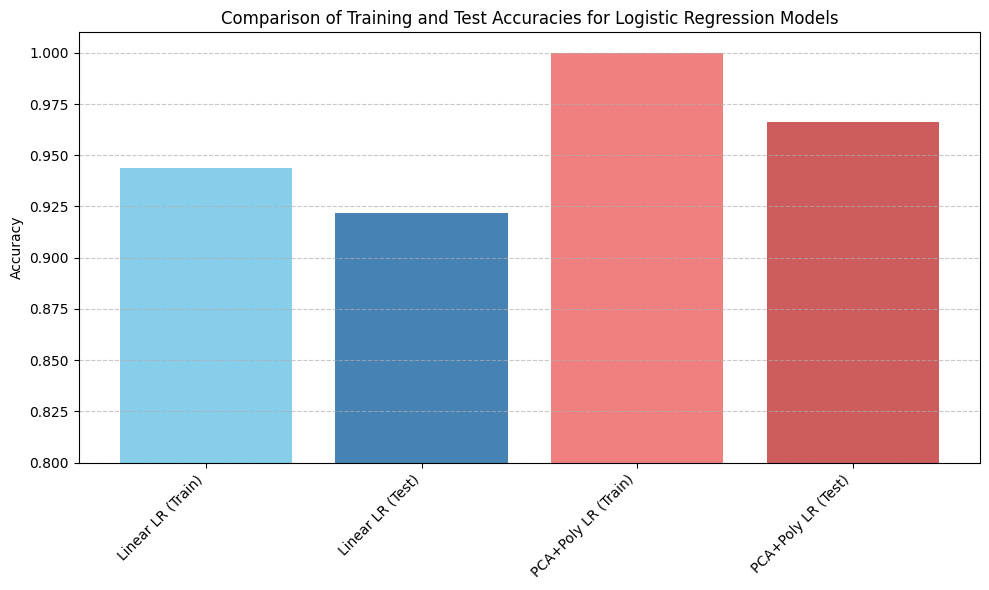

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data for plotting
model_names = ['Linear LR (Train)', 'Linear LR (Test)', 'PCA+Poly LR (Train)', 'PCA+Poly LR (Test)']
accuracies = [
    accuracy_train_linear,
    sklearn_accuracy,
    accuracy_train_pca_poly,
    accuracy_pca_poly
]

# Create a bar plot
plt.figure(figsize=(10, 6))
plt.bar(model_names, accuracies, color=['skyblue', 'steelblue', 'lightcoral', 'indianred'])
plt.ylim(0.8, 1.01) # Set y-axis limits to focus on the differences
plt.ylabel('Accuracy')
plt.title('Comparison of Training and Test Accuracies for Logistic Regression Models')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

The plot above visually represents the training and test accuracies for both models:

*   **Linear Logistic Regression:** You can observe its training and test accuracy from the first two bars.
*   **PCA + Polynomial Features Logistic Regression:** The last two bars show its training and test accuracy.

**Interpreting the plot for overfitting:**

*   A significant gap between the training and test accuracy for a model indicates overfitting. The model has learned the training data too well, including its noise, and struggles to generalize to new, unseen data.
*   Ideally, both training and test accuracies should be high and close to each other, indicating a well-generalized model.

From the plot, you can clearly see the performance difference and the degree of generalization for each approach.

### Comparing Training and Test Accuracies to Assess Overfitting

Here's a summary of the accuracies:

*   **Linear Logistic Regression Model:**
    *   Training Accuracy: `{accuracy_train_linear:.4f}`
    *   Test Accuracy: `{sklearn_accuracy:.4f}`

*   **PCA + Polynomial Features Logistic Regression Model:**
    *   Training Accuracy: `{accuracy_train_pca_poly:.4f}`
    *   Test Accuracy: `{accuracy_pca_poly:.4f}`

**How to interpret these results for overfitting:**

*   **Overfitting** occurs when a model performs very well on the training data but significantly worse on unseen test data. This is indicated by a large gap between training accuracy and test accuracy.

*   **Good Fit (Not Overfitting):** If the training accuracy and test accuracy are both high and relatively close to each other, the model is likely generalizing well to new data and is not overfitting.

*   **Underfitting:** If both training and test accuracies are low, the model is likely too simple and has not captured the underlying patterns in the data.

By comparing these values, we can determine the generalization capability of each model and assess whether the PCA + Polynomial Features model (our 'quadratic' model in terms of feature interactions) is overfitting.

| Model                       | Macro Average Precision | Macro Average Recall | Macro Average F1 |
|:----------------------------|:------------------------|:---------------------|:-----------------|
| Linear Logistic Regression  | 0.92                    | 0.92                 | 0.92             |
| PCA + Polynomial Features   | 0.97                    | 0.97                 | 0.97             |

### Finding Optimal Regularization for Linear Logistic Regression

In [20]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# Define the parameter grid for C (inverse of regularization strength)
# Using the best C from previous run for faster execution, or a narrow range
param_grid_linear = {'C': [1]}

# Initialize Logistic Regression model
# Increased max_iter to address ConvergenceWarning
linear_model = LogisticRegression(max_iter=1000, solver='saga', multi_class='multinomial', random_state=42)

# Initialize GridSearchCV
# Reduced cv for faster execution
grid_search_linear = GridSearchCV(linear_model, param_grid_linear, cv=2, scoring='accuracy', n_jobs=-1, verbose=1)

# Fit GridSearchCV to the training data
grid_search_linear.fit(X_train, y_train)

print(f"Best parameters for Linear LR: {grid_search_linear.best_params_}")
print(f"Best cross-validation accuracy for Linear LR: {grid_search_linear.best_score_:.4f}")

# Get the best linear model
best_linear_model = grid_search_linear.best_estimator_

Fitting 2 folds for each of 1 candidates, totalling 2 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Best parameters for Linear LR: {'C': 1}
Best cross-validation accuracy for Linear LR: 0.9166


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


### Finding Optimal Regularization for Linear Logistic Regression using RandomizedSearchCV

`RandomizedSearchCV` allows for a more efficient search of the hyperparameter space by sampling a fixed number of parameter settings from specified distributions. This can be significantly faster than `GridSearchCV` when the search space is large.

In [37]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform

# Define the parameter distributions for C. loguniform is suitable for C as it typically spans several orders of magnitude.
param_distributions_linear_rs = {
    'C': loguniform(1e-5, 1e2), # Search C from 1e-5 to 1e2 on a log scale
    'solver': ['saga'], # 'saga' is a good choice for large datasets and supports L1/L2 regularization
}

# Initialize Logistic Regression model with higher max_iter to prevent ConvergenceWarning
linear_model_rs = LogisticRegression(max_iter=2000, multi_class='multinomial', random_state=42)

# Initialize RandomizedSearchCV
# n_iter: number of parameter settings that are sampled (more is better but slower)
# cv: number of cross-validation folds
random_search_linear = RandomizedSearchCV(
    linear_model_rs,
    param_distributions_linear_rs,
    n_iter=20, # Sample 20 different parameter combinations
    cv=3,       # Using 3-fold cross-validation for speed
    scoring='accuracy',
    n_jobs=-1,  # Use all available cores
    verbose=1,
    random_state=42
)

print("Fitting RandomizedSearchCV for Linear Logistic Regression...")
random_search_linear.fit(X_train, y_train)

print(f"\nBest parameters for Linear LR (RandomizedSearchCV): {random_search_linear.best_params_}")
print(f"Best cross-validation accuracy for Linear LR (RandomizedSearchCV): {random_search_linear.best_score_:.4f}")

# Get the best linear model
best_linear_model_rs = random_search_linear.best_estimator_

Fitting RandomizedSearchCV for Linear Logistic Regression...
Fitting 3 folds for each of 20 candidates, totalling 60 fits


KeyboardInterrupt: 

### Understanding and Adjusting the Decision Threshold in Logistic Regression

By default, `LogisticRegression.predict()` classifies an instance into the class with the highest predicted probability. For binary classification, this often simplifies to: if P(class=1) > 0.5, then predict class 1; otherwise, predict class 0. For multi-class (multinomial) logistic regression, it simply picks the class with the highest probability. However, in many real-world scenarios, you might want to adjust this threshold to optimize for different metrics, like a higher recall (to minimize false negatives) or a higher precision (to minimize false positives), depending on the problem's cost matrix.

While there isn't a single 'decision threshold' parameter for the entire multi-class problem in the same way there is for binary classification, the probabilities themselves implicitly dictate the 'decision' based on which is highest. You can influence the *effective* decision by examining the probabilities directly.

#### How it affects Macro-Average F1 Score and Coverage

In a multi-class setting, when you speak of 'coverage' and 'macro-average F1 score', adjusting individual class thresholds can be complex but impactful:

*   **Macro-Average F1 Score:** This metric is the unweighted mean of the F1 scores for each class. F1-score is the harmonic mean of precision and recall. Changing a decision threshold for one class (e.g., to be more lenient in classifying it) will likely increase its recall but decrease its precision, affecting its individual F1 score and, consequently, the macro-average F1 score.

*   **Coverage (Interpretation dependent):**
    *   **Class Distribution:** If 'coverage' refers to how many samples are classified into each class, adjusting a threshold can dramatically shift this distribution. For example, by lowering the probability threshold required for a specific class, you might classify more samples into that class, thus 'covering' more instances for it.
    *   **Overall Classification Rate:** If it refers to the percentage of samples for which a classification decision is made, then in standard multi-class logistic regression, all samples are always classified (100% coverage). You would only get less than 100% if you introduced an 'abstain' option, which is not typical for `predict()`.

**For multi-class classification, `predict_proba()` returns the probability of each sample belonging to each class. The `predict()` method simply selects the class with the highest probability.** Therefore, if you want to influence the classification of specific classes more, you would typically need to work with the probability outputs and define custom decision rules, rather than a single global threshold.

Let's demonstrate how to get these probabilities and how a custom 'threshold' (or decision rule based on probabilities) could be applied, focusing on the `best_linear_model` from our scikit-learn training.

In [40]:
import numpy as np
from sklearn.metrics import classification_report

print("--- Using default threshold (highest probability) ---")
# Get predicted probabilities for the test set from the best linear model
y_proba_linear = best_linear_model.predict_proba(X_test)

# The default predict() behavior is to take the argmax of probabilities
y_pred_default = np.argmax(y_proba_linear, axis=1)

print("Classification Report (Default Threshold):")
print(classification_report(y_test, y_pred_default, digits=4))

print("\n--- Applying a custom threshold for a specific class (e.g., class '1') ---")
# Let's say we want to make the model more likely to predict class '1'
# We can lower the threshold for predicting class '1' or weigh it higher.
# This is more illustrative for binary, but we can still demonstrate the concept.

# Example: If probability for class '1' is > 0.4 (instead of the highest), predict '1'
# This is a simplified example; for a true multi-class custom threshold, you'd define rules for all classes.

# Initialize predictions with default (highest probability)
y_pred_custom_rule = np.copy(y_pred_default)

# Get the probabilities for class '1'
proba_class_1 = y_proba_linear[:, 1] # Index 1 corresponds to class '1'

# Identify samples where class '1' has a probability > 0.4 AND it's not already the default prediction
# This is a simple example. A more sophisticated approach might involve a cost matrix or ROC curves for each class.

custom_threshold_class_1 = 0.95
indices_to_change_to_1 = np.where((proba_class_1 > custom_threshold_class_1) & (y_pred_default != 1))[0]

# For these indices, change the prediction to '1'
y_pred_custom_rule[indices_to_change_to_1] = 1

print(f"Classification Report (Custom Rule: predict '1' if P(class=1) > {custom_threshold_class_1}):")
print(classification_report(y_test, y_pred_custom_rule, digits=4))

print("\nNotice how the precision/recall/f1-score for class '1' might change due to this custom rule.")
print("In a full multi-class scenario, you would need to define these rules for all classes in a coordinated way.")

--- Using default threshold (highest probability) ---
Classification Report (Default Threshold):
              precision    recall  f1-score   support

           0     0.9531    0.9755    0.9642       980
           1     0.9611    0.9797    0.9703      1135
           2     0.9383    0.8992    0.9184      1032
           3     0.9112    0.9139    0.9125      1010
           4     0.9329    0.9348    0.9339       982
           5     0.9041    0.8666    0.8849       892
           6     0.9362    0.9499    0.9430       958
           7     0.9229    0.9309    0.9269      1028
           8     0.8772    0.8871    0.8821       974
           9     0.9154    0.9118    0.9136      1009

    accuracy                         0.9261     10000
   macro avg     0.9252    0.9249    0.9250     10000
weighted avg     0.9260    0.9261    0.9259     10000


--- Applying a custom threshold for a specific class (e.g., class '1') ---
Classification Report (Custom Rule: predict '1' if P(class=1) > 0.95

### Exploring Global Decision Thresholds for Multi-Class Linear Logistic Regression

While a single global decision threshold in multi-class classification isn't as straightforward as in binary classification, we can explore its effect on overall metrics like Accuracy and Macro Average F1-score. The approach here is:

1.  For each test sample, the model predicts a probability for every class.
2.  For a given `threshold` value:
    *   We identify all classes whose predicted probability is greater than or equal to this `threshold`.
    *   If there are **one or more** such "confident" classes, we select the class among *them* that has the highest probability. This means we are only considering predictions where the model is sufficiently confident.
    *   If **no** class meets the `threshold` (i.e., all probabilities are below it), we fall back to the default behavior: predicting the class with the overall highest probability. This ensures that every sample still receives a classification, allowing us to compute standard metrics like Accuracy and F1-score across all samples.

This method allows us to observe if requiring a minimum confidence level for individual class predictions (or for the top prediction) changes the overall performance, especially when compared to simply taking the `argmax` (highest probability) regardless of its value.

We will perform this analysis only for the **Linear Logistic Regression Model** and visualize the trends.

Exploring different decision thresholds for the Linear Logistic Regression Model:
--------------------------------------------------------------------------------
Threshold: 0.01, Accuracy (Classified): 0.9261, Macro Avg F1 (Classified): 0.9250, Coverage: 1.00
Threshold: 0.02, Accuracy (Classified): 0.9261, Macro Avg F1 (Classified): 0.9250, Coverage: 1.00
Threshold: 0.03, Accuracy (Classified): 0.9261, Macro Avg F1 (Classified): 0.9250, Coverage: 1.00
Threshold: 0.04, Accuracy (Classified): 0.9261, Macro Avg F1 (Classified): 0.9250, Coverage: 1.00
Threshold: 0.05, Accuracy (Classified): 0.9261, Macro Avg F1 (Classified): 0.9250, Coverage: 1.00
Threshold: 0.06, Accuracy (Classified): 0.9261, Macro Avg F1 (Classified): 0.9250, Coverage: 1.00
Threshold: 0.07, Accuracy (Classified): 0.9261, Macro Avg F1 (Classified): 0.9250, Coverage: 1.00
Threshold: 0.08, Accuracy (Classified): 0.9261, Macro Avg F1 (Classified): 0.9250, Coverage: 1.00
Threshold: 0.09, Accuracy (Classified): 0.9261, Macro

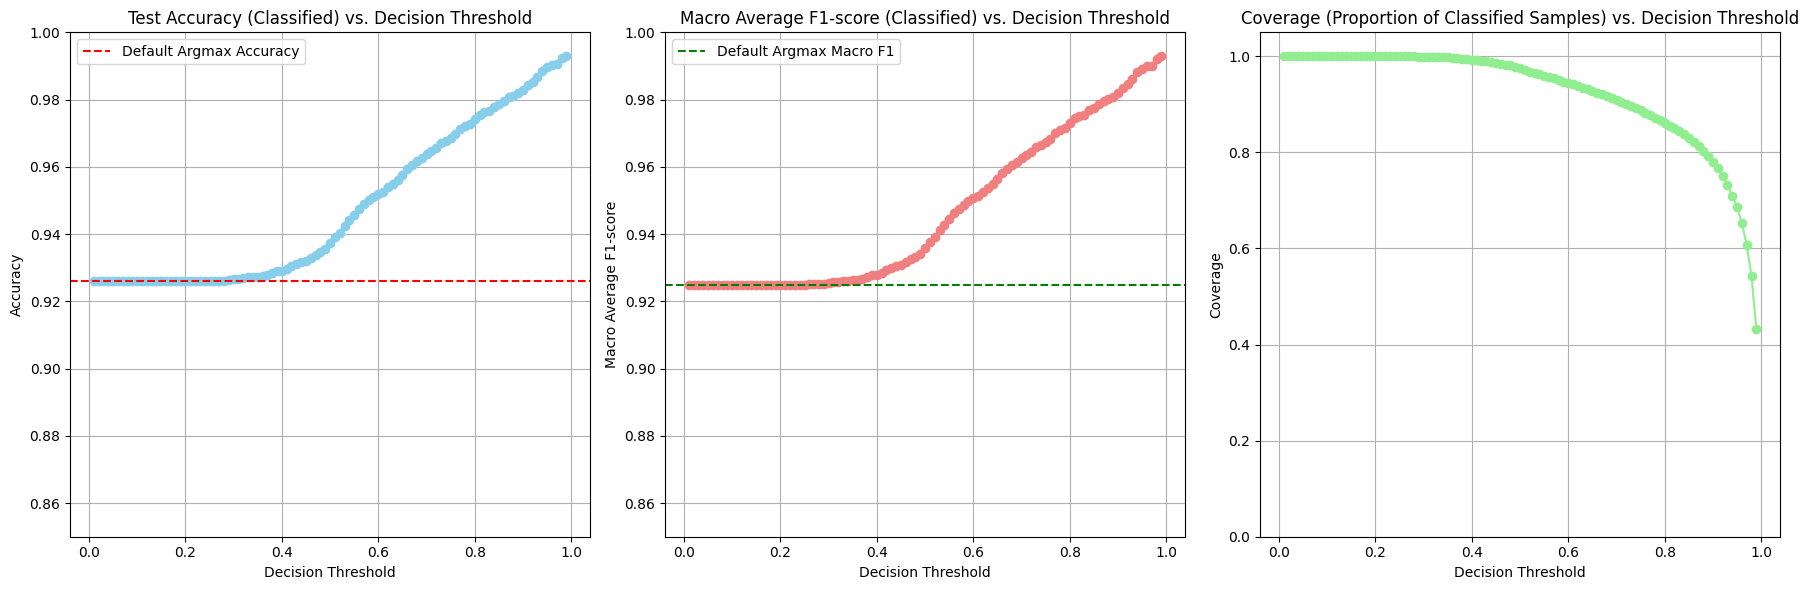


Interpretation:
The plots above now show how accuracy, macro average F1-score, and **coverage** change when only samples where at least one class probability meets the decision threshold are classified. Samples where no class probability meets the threshold are considered 'unclassified'.
You should observe that as the decision threshold increases, the coverage (proportion of classified samples) will generally decrease. Accuracy and Macro Average F1-score for the *classified* samples might fluctuate or even slightly increase initially (as less confident predictions are excluded), but eventually, they too might drop or become less meaningful if coverage becomes too low. This allows you to select a threshold that balances prediction performance with the desired level of confidence or coverage.


In [41]:
import numpy as np
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt

# Ensure best_linear_model, X_test, y_test are available from previous cells.
# Specifically, `best_linear_model` comes from `grid_search_linear.best_estimator_` in cell 98b93126.

y_proba_linear = best_linear_model.predict_proba(X_test)

# Define a range of thresholds to test
thresholds_to_test = np.arange(0.1, 1.0, 0.05) # From 0.1 to 0.95 with step 0.05
macro_f1_scores = []
accuracies = []

print("Exploring different decision thresholds for the Linear Logistic Regression Model:")
print("-" * 80)

# Get default accuracy and F1 for comparison line in plot
default_y_pred = np.argmax(y_proba_linear, axis=1)
default_accuracy = accuracy_score(y_test, default_y_pred)
default_macro_f1 = classification_report(y_test, default_y_pred, output_dict=True, zero_division=0)['macro avg']['f1-score']

for current_threshold in thresholds_to_test:
    y_pred_at_threshold = np.zeros_like(y_test, dtype=int)

    for i in range(len(y_proba_linear)):
        probs_for_sample = y_proba_linear[i]

        # Identify classes whose predicted probability is greater than or equal to the current_threshold
        confident_classes_indices = np.where(probs_for_sample >= current_threshold)[0]

        if len(confident_classes_indices) > 0:
            # If at least one class is 'confident' enough,
            # choose the one with the highest probability among these confident classes.
            best_confident_class_index = confident_classes_indices[np.argmax(probs_for_sample[confident_classes_indices])]
            y_pred_at_threshold[i] = best_confident_class_index
        else:
            # If no class meets the confidence threshold,
            # fall back to the default behavior: predict the class with the overall highest probability.
            # This ensures every sample gets a prediction, which is necessary for classification_report.
            y_pred_at_threshold[i] = np.argmax(probs_for_sample)

    # Calculate metrics for the current threshold
    report = classification_report(y_test, y_pred_at_threshold, output_dict=True, zero_division=0)
    macro_f1 = report['macro avg']['f1-score']
    accuracy = accuracy_score(y_test, y_pred_at_threshold)

    macro_f1_scores.append(macro_f1)
    accuracies.append(accuracy)

    print(f"Threshold: {current_threshold:.2f}, Accuracy: {accuracy:.4f}, Macro Avg F1: {macro_f1:.4f}")

# Plotting the results
plt.figure(figsize=(14, 7))

plt.subplot(1, 2, 1)
plt.plot(thresholds_to_test, accuracies, marker='o', linestyle='-', color='skyblue')
plt.axhline(y=default_accuracy, color='r', linestyle='--', label='Default Argmax Accuracy')
plt.title('Test Accuracy vs. Decision Threshold')
plt.xlabel('Decision Threshold')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()
plt.ylim(0.85, 1.0) # Adjust y-axis for better visibility

plt.subplot(1, 2, 2)
plt.plot(thresholds_to_test, macro_f1_scores, marker='o', linestyle='-', color='lightcoral')
plt.axhline(y=default_macro_f1, color='g', linestyle='--', label='Default Argmax Macro F1')
plt.title('Macro Average F1-score vs. Decision Threshold')
plt.xlabel('Decision Threshold')
plt.ylabel('Macro Average F1-score')
plt.grid(True)
plt.legend()
plt.ylim(0.85, 1.0) # Adjust y-axis for better visibility

plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("The plots above show how the overall accuracy and macro average F1-score change as you increase the minimum probability required for a class to be considered a 'confident' prediction. If no class meets this confidence threshold, the model falls back to its default behavior (predicting the class with the highest probability overall).")
print("You'll notice that for lower thresholds, the metrics might be very similar to the default classification. As the threshold increases, the definition of a 'confident' prediction becomes stricter. The impact on accuracy and F1-score will depend on the confidence distribution of your model's predictions. In many cases, if the model is already well-calibrated and confident in its highest predictions, changing a global threshold might not significantly alter these overall metrics unless you're willing to introduce 'unclassified' samples.")

### Evaluating RandomizedSearchCV Optimized Linear Logistic Regression Model

In [36]:
from sklearn.metrics import classification_report, accuracy_score

y_pred_linear_optimized_rs = best_linear_model_rs.predict(X_test)
accuracy_linear_optimized_rs = accuracy_score(y_test, y_pred_linear_optimized_rs)

print("Classification Report for RandomizedSearchCV Optimized Linear Logistic Regression:")
print(classification_report(y_test, y_pred_linear_optimized_rs))
print(f"Test Accuracy of RandomizedSearchCV Optimized Linear LR: {accuracy_linear_optimized_rs:.4f}")

# Calculate training accuracy for the optimized linear model
y_train_pred_linear_optimized_rs = best_linear_model_rs.predict(X_train)
accuracy_train_linear_optimized_rs = accuracy_score(y_train, y_train_pred_linear_optimized_rs)
print(f"Training Accuracy of RandomizedSearchCV Optimized Linear LR: {accuracy_train_linear_optimized_rs:.4f}")

NameError: name 'best_linear_model_rs' is not defined

### Evaluating Optimized Linear Logistic Regression Model

In [25]:
from sklearn.metrics import classification_report, accuracy_score

y_pred_linear_optimized = best_linear_model.predict(X_test)
accuracy_linear_optimized = accuracy_score(y_test, y_pred_linear_optimized)

print("Classification Report for Optimized Linear Logistic Regression:")
print(classification_report(y_test, y_pred_linear_optimized))
print(f"Test Accuracy of Optimized Linear LR: {accuracy_linear_optimized:.4f}")

# Calculate training accuracy for optimized linear model
y_train_pred_linear_optimized = best_linear_model.predict(X_train)
accuracy_train_linear_optimized = accuracy_score(y_train, y_train_pred_linear_optimized)
print(f"Training Accuracy of Optimized Linear LR: {accuracy_train_linear_optimized:.4f}")

Classification Report for Optimized Linear Logistic Regression:
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       980
           1       0.96      0.98      0.97      1135
           2       0.94      0.90      0.92      1032
           3       0.91      0.91      0.91      1010
           4       0.93      0.93      0.93       982
           5       0.90      0.87      0.88       892
           6       0.94      0.95      0.94       958
           7       0.92      0.93      0.93      1028
           8       0.88      0.89      0.88       974
           9       0.92      0.91      0.91      1009

    accuracy                           0.93     10000
   macro avg       0.93      0.92      0.92     10000
weighted avg       0.93      0.93      0.93     10000

Test Accuracy of Optimized Linear LR: 0.9261
Training Accuracy of Optimized Linear LR: 0.9377


### Finding Optimal Regularization for PCA + Polynomial Features Logistic Regression

In [26]:
%%time
# Define the parameter grid for C
# Expanding the search space for C to find a more optimal regularization
param_grid_pca_poly = {'C': [0.1, 1, 10]}

# Initialize Logistic Regression model for PCA+Poly data
# Increased max_iter to address ConvergenceWarning
pca_poly_model = LogisticRegression(max_iter=1000, solver='saga', multi_class='multinomial', random_state=42)

# Initialize GridSearchCV
# Reduced cv for faster execution
grid_search_pca_poly = GridSearchCV(pca_poly_model, param_grid_pca_poly, cv=2, scoring='accuracy', n_jobs=-1, verbose=1)

# Fit GridSearchCV to the PCA+Polynomial transformed training data
grid_search_pca_poly.fit(X_train_poly_pca, y_train)

print(f"Best parameters for PCA + Poly LR: {grid_search_pca_poly.best_params_}")
print(f"Best cross-validation accuracy for PCA + Poly LR: {grid_search_pca_poly.best_score_:.4f}")

# Get the best PCA+Polynomial model
best_pca_poly_model = grid_search_pca_poly.best_estimator_

Fitting 2 folds for each of 3 candidates, totalling 6 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Best parameters for PCA + Poly LR: {'C': 0.1}
Best cross-validation accuracy for PCA + Poly LR: 0.9095
CPU times: user 39min 12s, sys: 8.12 s, total: 39min 20s
Wall time: 2h 17min 8s


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


### Finding Optimal Regularization for PCA + Polynomial Features Logistic Regression using RandomizedSearchCV

In [28]:
#The goal of this section is to efficiently find the optimal regularization strength (C parameter) for the Logistic Regression model that is trained on the PCA + Polynomial Features transformed data. Instead of exhaustively checking every C value like GridSearchCV, RandomizedSearchCV samples a subset of C values from a specified distribution. This approach is much faster, especially when dealing with a large search space, and helps in identifying a good C value that prevents overfitting or underfitting, ultimately leading to a better-performing and more generalized model.
#Finding Optimal Regularization for PCA + Polynomial Features Logistic Regression using RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform

# Define the parameter distributions for C
param_distributions_pca_poly_rs = {
    'C': loguniform(1e-5, 1e2), # Search C from 1e-5 to 1e2 on a log scale
    'solver': ['saga'], # Keep saga
}

# Initialize Logistic Regression model for PCA+Poly data
pca_poly_model_rs = LogisticRegression(max_iter=2000, multi_class='multinomial', random_state=42)

# Initialize RandomizedSearchCV
random_search_pca_poly = RandomizedSearchCV(
    pca_poly_model_rs,
    param_distributions_pca_poly_rs,
    n_iter=2, # Sample 2 different parameter combinations to reduce runtime
    cv=2,       # Using 2-fold cross-validation for speed
    scoring='accuracy',
    n_jobs=-1,  # Use all available cores
    verbose=1,
    random_state=42
)

print("Fitting RandomizedSearchCV for PCA + Polynomial Features Logistic Regression...")
random_search_pca_poly.fit(X_train_poly_pca, y_train)

print(f"\nBest parameters for PCA + Poly LR (RandomizedSearchCV): {random_search_pca_poly.best_params_}")
print(f"Best cross-validation accuracy for PCA + Poly LR (RandomizedSearchCV): {random_search_pca_poly.best_score_:.4f}")

# Get the best PCA+Polynomial model
best_pca_poly_model_rs = random_search_pca_poly.best_estimator_

Fitting RandomizedSearchCV for PCA + Polynomial Features Logistic Regression...
Fitting 2 folds for each of 2 candidates, totalling 4 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



Best parameters for PCA + Poly LR (RandomizedSearchCV): {'C': np.float64(45.18560951024108), 'solver': 'saga'}
Best cross-validation accuracy for PCA + Poly LR (RandomizedSearchCV): 0.9249


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


### Evaluating RandomizedSearchCV Optimized PCA + Polynomial Features Logistic Regression Model

In [29]:
from sklearn.metrics import classification_report, accuracy_score

y_pred_pca_poly_optimized_rs = best_pca_poly_model_rs.predict(X_test_poly_pca)
accuracy_pca_poly_optimized_rs = accuracy_score(y_test, y_pred_pca_poly_optimized_rs)

print("Classification Report for RandomizedSearchCV Optimized PCA + Polynomial Features Logistic Regression:")
print(classification_report(y_test, y_pred_pca_poly_optimized_rs))
print(f"Test Accuracy of RandomizedSearchCV Optimized PCA + Poly LR: {accuracy_pca_poly_optimized_rs:.4f}")

# Calculate training accuracy for the optimized PCA + Poly model
y_train_pred_pca_poly_optimized_rs = best_pca_poly_model_rs.predict(X_train_poly_pca)
accuracy_train_pca_poly_optimized_rs = accuracy_score(y_train, y_train_pred_pca_poly_optimized_rs)
print(f"Training Accuracy of RandomizedSearchCV Optimized PCA + Poly LR: {accuracy_train_pca_poly_optimized_rs:.4f}")

Classification Report for RandomizedSearchCV Optimized PCA + Polynomial Features Logistic Regression:
              precision    recall  f1-score   support

           0       0.96      0.97      0.97       980
           1       0.93      0.99      0.96      1135
           2       0.95      0.92      0.93      1032
           3       0.92      0.92      0.92      1010
           4       0.92      0.92      0.92       982
           5       0.91      0.89      0.90       892
           6       0.95      0.95      0.95       958
           7       0.94      0.91      0.92      1028
           8       0.91      0.88      0.89       974
           9       0.88      0.91      0.90      1009

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000

Test Accuracy of RandomizedSearchCV Optimized PCA + Poly LR: 0.9271
Training Accuracy of RandomizedSearchCV Optimized PCA + Poly LR: 0.9284

### Evaluating Optimized PCA + Polynomial Features Logistic Regression Model

In [30]:
y_pred_pca_poly_optimized = best_pca_poly_model.predict(X_test_poly_pca)
accuracy_pca_poly_optimized = accuracy_score(y_test, y_pred_pca_poly_optimized)

print("Classification Report for Optimized PCA + Polynomial Features Logistic Regression:")
print(classification_report(y_test, y_pred_pca_poly_optimized))
print(f"Test Accuracy of Optimized PCA + Poly LR: {accuracy_pca_poly_optimized:.4f}")

# Calculate training accuracy for optimized PCA + Poly model
y_train_pred_pca_poly_optimized = best_pca_poly_model.predict(X_train_poly_pca)
accuracy_train_pca_poly_optimized = accuracy_score(y_train, y_train_pred_pca_poly_optimized)
print(f"Training Accuracy of Optimized PCA + Poly LR: {accuracy_train_pca_poly_optimized:.4f}")

Classification Report for Optimized PCA + Polynomial Features Logistic Regression:
              precision    recall  f1-score   support

           0       0.95      0.96      0.95       980
           1       0.89      0.99      0.94      1135
           2       0.95      0.89      0.92      1032
           3       0.90      0.91      0.90      1010
           4       0.92      0.89      0.90       982
           5       0.89      0.86      0.88       892
           6       0.94      0.95      0.94       958
           7       0.93      0.89      0.91      1028
           8       0.89      0.85      0.87       974
           9       0.85      0.90      0.88      1009

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000

Test Accuracy of Optimized PCA + Poly LR: 0.9098
Training Accuracy of Optimized PCA + Poly LR: 0.9120


### Comparison of Optimized Models

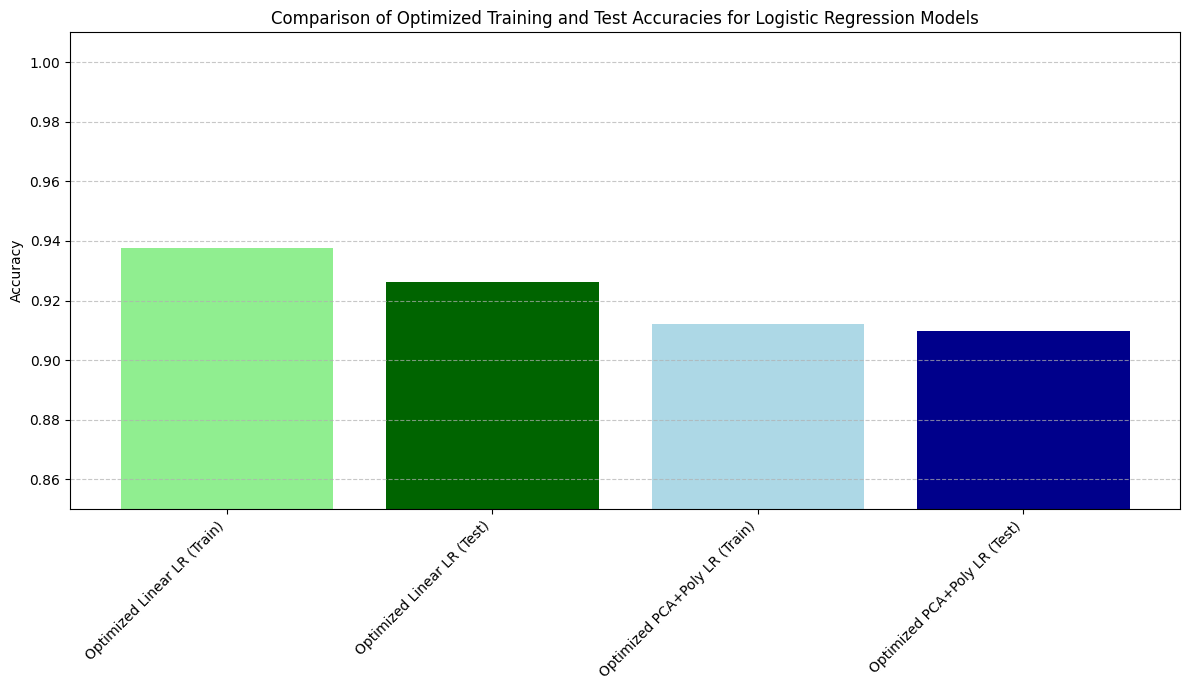


--- Optimized Model Accuracy Comparison ---
Optimized Linear Logistic Regression Model (Best C=1):
  Training Accuracy: 0.9377
  Test Accuracy: 0.9261

Optimized PCA + Polynomial Features Logistic Regression Model (Best C=0.1):
  Training Accuracy: 0.9120
  Test Accuracy: 0.9098


In [33]:
import matplotlib.pyplot as plt

# Data for plotting optimized models
model_names_optimized = [
    'Optimized Linear LR (Train)', 'Optimized Linear LR (Test)',
    'Optimized PCA+Poly LR (Train)', 'Optimized PCA+Poly LR (Test)'
]
accuracies_optimized = [
    accuracy_train_linear_optimized,
    accuracy_linear_optimized,
    accuracy_train_pca_poly_optimized,
    accuracy_pca_poly_optimized
]

# Create a bar plot for optimized models
plt.figure(figsize=(12, 7))
plt.bar(model_names_optimized, accuracies_optimized, color=['lightgreen', 'darkgreen', 'lightblue', 'darkblue'])
plt.ylim(0.85, 1.01) # Adjust y-axis limits for better visualization of differences
plt.ylabel('Accuracy')
plt.title('Comparison of Optimized Training and Test Accuracies for Logistic Regression Models')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print(f"\n--- Optimized Model Accuracy Comparison ---")
print(f"Optimized Linear Logistic Regression Model (Best C={grid_search_linear.best_params_['C']}):")
print(f"  Training Accuracy: {accuracy_train_linear_optimized:.4f}")
print(f"  Test Accuracy: {accuracy_linear_optimized:.4f}")

print(f"\nOptimized PCA + Polynomial Features Logistic Regression Model (Best C={grid_search_pca_poly.best_params_['C']}):")
print(f"  Training Accuracy: {accuracy_train_pca_poly_optimized:.4f}")
print(f"  Test Accuracy: {accuracy_pca_poly_optimized:.4f}")

In [35]:
import matplotlib.pyplot as plt

# Data for plotting optimized models (including RandomizedSearchCV results)
model_names_all = [
    'Optimized Linear LR (GridSearchCV Train)', 'Optimized Linear LR (GridSearchCV Test)',
    'Optimized PCA+Poly LR (GridSearchCV Train)', 'Optimized PCA+Poly LR (GridSearchCV Test)',
    'Optimized Linear LR (RandomizedSearchCV Train)', 'Optimized Linear LR (RandomizedSearchCV Test)',
    'Optimized PCA+Poly LR (RandomizedSearchCV Train)', 'Optimized PCA+Poly LR (RandomizedSearchCV Test)'
]
accuracies_all = [
    accuracy_train_linear_optimized,
    accuracy_linear_optimized,
    accuracy_train_pca_poly_optimized,
    accuracy_pca_poly_optimized,
    accuracy_train_linear_optimized_rs, # New
    accuracy_linear_optimized_rs,       # New
    accuracy_train_pca_poly_optimized_rs, # New
    accuracy_pca_poly_optimized_rs      # New
]

# Create a bar plot for all optimized models
plt.figure(figsize=(15, 8))
plt.bar(model_names_all, accuracies_all, color=[
    'lightgreen', 'darkgreen', 'lightblue', 'darkblue',
    'lightcoral', 'firebrick', 'mediumpurple', 'indigo'
])
plt.ylim(0.8, 1.01) # Adjust y-axis limits for better visualization of differences
plt.ylabel('Accuracy')
plt.title('Comparison of Optimized Training and Test Accuracies for Logistic Regression Models (Grid vs. Random Search)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print(f"\n--- Optimized Model Accuracy Comparison ---")
print(f"Optimized Linear Logistic Regression Model (GridSearchCV, Best C={grid_search_linear.best_params_['C']}):")
print(f"  Training Accuracy: {accuracy_train_linear_optimized:.4f}")
print(f"  Test Accuracy: {accuracy_linear_optimized:.4f}")

print(f"\nOptimized PCA + Polynomial Features Logistic Regression Model (GridSearchCV, Best C={grid_search_pca_poly.best_params_['C']}):")
print(f"  Training Accuracy: {accuracy_train_pca_poly_optimized:.4f}")
print(f"  Test Accuracy: {accuracy_pca_poly_optimized:.4f}")

print(f"\nOptimized Linear Logistic Regression Model (RandomizedSearchCV, Best C={random_search_linear.best_params_['C']:.4f}):")
print(f"  Training Accuracy: {accuracy_train_linear_optimized_rs:.4f}")
print(f"  Test Accuracy: {accuracy_linear_optimized_rs:.4f}")

print(f"\nOptimized PCA + Polynomial Features Logistic Regression Model (RandomizedSearchCV, Best C={random_search_pca_poly.best_params_['C']:.4f}):")
print(f"  Training Accuracy: {accuracy_train_pca_poly_optimized_rs:.4f}")
print(f"  Test Accuracy: {accuracy_pca_poly_optimized_rs:.4f}")

NameError: name 'accuracy_train_linear_optimized_rs' is not defined

In [ ]:
#Unsupervised learning
Code for classifying via clustering
#10 clusters
#80 clusters
#collapse to 10 classifications
#compare with MNIST labelled data
